# 🧪 Analíticas de sangre (tabular) — Comparativa multi-arquitectura (v1 · CPU · modelo independiente)
## TFM · Módulo Tabular (Laboratorio) · Universidad de Salamanca

---

## 🎯 Qué es este notebook

Clasifica las 6 etiquetas cardiopulmonares (Atelectasis, Cardiomegaly, Edema, Lung Opacity, No Finding,
Pleural Effusion) **solo a partir de las analíticas de sangre y datos clínicos de contexto**. Es un modelo
**independiente** (sin fusión). Prueba **5 arquitecturas**, las compara, elige la mejor y la entrena en serio.

## 🩺 Decisiones de datos (las más importantes)

**1. ¿Valores brutos (raw) o percentiles? → LAS DOS, cada una donde rinde mejor.**
- **Modelos de árboles (XGBoost, LightGBM): valores RAW con NaN nativo.** El EDA demostró ΔAUC=0 entre raw y percentil para árboles (invariantes a transformaciones monótonas) y gestionan el NaN solos.
- **Modelos densos (Regresión Logística, MLP, TabPFN): PERCENTIL** (ya en [0,1], normaliza las distribuciones asimétricas), **imputando los NaN con la media de train** (método de Symile) y estandarizando.

**2. Tratamiento de NaN.** Árboles → NaN nativo. Densos → imputación por media de percentil de train. Además, se añaden **indicadores binarios de missingness (1/0)** para las analíticas con missingness no trivial (>2%), porque el patrón **MNAR es predictivo** (EDA Bloque 14: Edema/Derrame tienen menos missingness en gases). Esto separa el efecto del *valor* del efecto de la *ausencia*.

**3. Selección de variables.** Se mantienen las **41 analíticas** (los árboles gestionan la redundancia de clusters; la importancia ya las ordena). No se eliminan a ciegas: el clustering del EDA se observa en la importancia.

**4. Variables de contexto** (todas): edad, sexo, raza, tipo de ingreso, lugar de ingreso, vista y horas desde el ingreso.

## 🤖 Arquitecturas comparadas (5)

| Modelo | Familia | Representación | Desequilibrio |
|---|---|---|---|
| **XGBoost** | Boosting de árboles | raw + NaN | `scale_pos_weight` por etiqueta |
| **LightGBM** | Boosting de árboles | raw + NaN | `scale_pos_weight` por etiqueta |
| **Regresión Logística** | Lineal | percentil imputado + estand. | `class_weight=balanced` |
| **MLP** | Red neuronal | percentil imputado + estand. | `pos_weight` dinámico / focal |
| **TabPFN** | Transformer tabular **preentrenado** | percentil imputado | preentrenado (robusto al desequilibrio) |

> **¿Pesos preentrenados para tabular?** Sí: **TabPFN** es un transformer entrenado sobre millones de tareas
> sintéticas que clasifica *en contexto* sin entrenar, ideal con ≤10.000 muestras y ~100 features — justo este caso.

## 🩻 Estrategia multilabel + No Finding

- **Enmascarado** de etiquetas no observadas (NaN) — solo entran en la pérdida las observadas.
- **Negativos derivados por exclusividad** con *No Finding* (si No Finding=1 → patologías=0; si alguna patología=1 → No Finding=0). Solo rellena NaN; nunca pisa valores explícitos ni inciertos.
- En árboles/lineal se entrena **un clasificador por etiqueta** (one-vs-rest) **solo sobre las muestras observadas** de esa etiqueta; en MLP, pérdida multilabel enmascarada.

## 📊 Salidas

Comparativa entre arquitecturas con **diagrama de cajas de AUC**, tabla de macro-AUC, **matrices de confusión**,
y elección del mejor modelo → **tuning con Optuna + entrenamiento final + evaluación en test** + **importancia de
variables con nombres legibles** (nombre + código + significado clínico).

## ⚠️ Notas

- **No usa ningún `.npy`**: todo está en los CSV limpios (analíticas + etiquetas + contexto). El test son **464** filas (subconjunto etiquetado intencional); no hay problema de alineación.
- Coste en CPU: bajo-medio (datos tabulares). La comparativa son minutos; TabPFN es lo más lento.


In [1]:
# CELDA 1 · DEPENDENCIAS
import subprocess, sys
try:
    import torch  # noqa: F401
except ImportError:
    subprocess.run([sys.executable,"-m","pip","install","torch","--index-url","https://download.pytorch.org/whl/cpu","-q"], check=True)
for pkg in ["xgboost","lightgbm","scikit-learn","optuna","pandas","numpy","matplotlib","seaborn","tqdm"]:
    subprocess.run([sys.executable,"-m","pip","install",pkg,"-q"], check=True)
try:
    subprocess.run([sys.executable,"-m","pip","install","tabpfn-client","-q"], check=True)
    print("TabPFN client instalado.")
except Exception as ex:
    print("TabPFN client no se pudo instalar (se omitirá):", ex)
print("Dependencias instaladas.")

TabPFN client instalado.
Dependencias instaladas.


In [2]:
# CELDA 2 · IMPORTS / SEMILLAS / DISPOSITIVO
import os, gc, json, time, copy, random, warnings
from pathlib import Path
from collections import Counter
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from tqdm.auto import tqdm
import torch, torch.nn as nn, torch.nn.functional as F
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             confusion_matrix, roc_curve, precision_recall_curve)
import xgboost as xgb
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING); warnings.filterwarnings("ignore")
try:
    from tabpfn import TabPFNClassifier
    TABPFN_OK = True
except Exception:
    TABPFN_OK = False
SEED=42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.set_num_threads(4)
DEVICE=torch.device("cpu")
print(f"xgboost {xgb.__version__} · lightgbm {lgb.__version__} · TabPFN disponible: {TABPFN_OK}")


c:\TFM\1.Opción - Symile Mimic\tfm_multimodal_clinico\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


xgboost 2.1.4 · lightgbm 4.6.0 · TabPFN disponible: True


In [3]:
# CELDA 3 · RUTAS, ETIQUETAS Y CONSTANTES
# El proyecto tiene los CSV limpios en dos sitios equivalentes; se usa el del dataset.
BASE=Path(r"C:\TFM\1.Opción - Symile Mimic\symile-mimic-a-multimodal-clinical-dataset-of-chest-x-rays-electrocardiograms-and-blood-labs-from-mimic-iv-1.0.0")
CSV_DIR=BASE/"data_csv"/"clean"
TRAIN_CSV,VAL_CSV,TEST_CSV=CSV_DIR/"train_clean.csv",CSV_DIR/"val_clean.csv",CSV_DIR/"test_clean.csv"
OUTPUT_DIR=Path("outputs_labs_tabular_v1").resolve(); OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
FIG_DIR=OUTPUT_DIR/"figuras"; FIG_DIR.mkdir(parents=True,exist_ok=True)
print("Salidas en:", OUTPUT_DIR)

LABELS=["Atelectasis","Cardiomegaly","Edema","Lung Opacity","No Finding","Pleural Effusion"]
N_LABELS=len(LABELS); NO_FINDING="No Finding"
PATHOLOGY_LABELS=[l for l in LABELS if l!=NO_FINDING]; CORE_LABELS=["Cardiomegaly","Edema","Pleural Effusion"]
DERIVE_NEGATIVES_FROM_EXCLUSIVITY=True
FLAG_THRESH=0.02          # flag de missingness si missingness(train) > 2%
K_COMPARE=3               # K-fold para la comparativa entre arquitecturas
OPTUNA_TRIALS_BEST=30     # tuning del mejor modelo
USE_TABPFN=TABPFN_OK; TABPFN_MAX=4000   # límite de contexto para TabPFN en CPU

# Contexto clínico
GENDER_MAP={0:0,1:1,"0":0,"1":1,"M":1,"F":0}
RACE_MAP={"UNKNOWN":0,"WHITE":1,"BLACK":2,"ASIAN":3,"HISPANIC_LATINO":4,"OTHER_KNOWN":0}
ADMISSION_MAP={"SCHEDULED":0,"EMERGENCY":1,"OBSERVATION":2,"URGENT":3}
ADM_LOC_MAP={"EMERGENCY_ROOM":0,"REFERRAL":1,"TRANSFER":2,"INTRA_HOSPITAL":3}
CXR_VIEW_MAP={"AP":0,"PA":1}; RACE_ONEHOT=5

# Significado clínico breve para nombres legibles en la importancia de variables
LAB_MEANING={
 "urea_nitrogen":"función renal/gravedad","albumin":"proteína; baja en efusiones/ICC","rdw":"anisocitosis; fallo cardíaco",
 "creatinine":"función renal","lymphocytes_pct":"inflamación/inmunidad","hemoglobin":"anemia","hematocrit":"anemia",
 "rbc":"masa eritrocitaria","mch":"índice eritrocitario","mchc":"índice eritrocitario","mcv":"índice eritrocitario",
 "nrbc_abs":"estrés medular","pt":"coagulación","inr_pt":"coagulación/hepático","ptt":"coagulación",
 "phosphate":"metabólico","calcium_total":"metabólico","magnesium":"metabólico","sodium":"electrolito/renal",
 "potassium":"electrolito/renal","chloride":"electrolito","bicarbonate":"ácido-base","anion_gap":"ácido-base",
 "base_excess":"ácido-base","ph":"ácido-base","pco2":"gases","po2":"gases","calculated_total_co2":"ácido-base",
 "lactate":"hipoperfusión","glucose":"metabólico","alt":"hepático","ast":"hepático",
 "alkaline_phosphatase":"hepático/óseo","bilirubin_total":"hepático","fibrinogen":"coagulación/inflamación",
 "wbc_count":"inflamación","neutrophils_pct":"inflamación","monocytes_pct":"inmunidad",
 "basophils_pct":"inmunidad","eosinophils_pct":"alergia/inmunidad","platelet_count":"hemostasia"}

def readable(col):
    name,code=col.rsplit("_",1); pretty=name.replace("_"," ").title()
    mn=LAB_MEANING.get(name,"")
    return f"{pretty} ({code})"+(f" – {mn}" if mn else "")
print("Constantes listas.")


Salidas en: C:\TFM\1.Opción - Symile Mimic\tfm_multimodal_clinico\notebooks\outputs_labs_tabular_v1
Constantes listas.


In [4]:
# CELDA 4 · CARGA DE CSV (sin npy: analíticas, etiquetas y contexto están aquí)
df_train=pd.read_csv(TRAIN_CSV,sep=";"); df_val=pd.read_csv(VAL_CSV,sep=";"); df_test=pd.read_csv(TEST_CSV,sep=";")
DEMO=["subject_id","hadm_id","cxr_path","ecg_path","age","gender","race","admission_type",
      "admission_location","cxr_view","hours_adm_to_cxr"]
RAW_LABS=[c for c in df_train.columns if c not in LABELS and c not in DEMO and "pctile" not in c]
PCT_LABS=[c for c in df_train.columns if "pctile" in c]
print(f"train={len(df_train)} val={len(df_val)} test={len(df_test)} | raw labs={len(RAW_LABS)} percentil={len(PCT_LABS)}")


train=10000 val=750 test=464 | raw labs=41 percentil=41


In [5]:
# CELDA 5 · OBJETIVOS (masking + negativos derivados por exclusividad)
def build_targets(df,uncertainty_policy="zeros",derive=DERIVE_NEGATIVES_FROM_EXCLUSIVITY,verbose=False):
    raw=df[LABELS].to_numpy(dtype=float); N=raw.shape[0]
    labels=np.zeros((N,N_LABELS),np.float32); mask=np.zeros((N,N_LABELS),np.float32)
    mask[~np.isnan(raw)]=1.0; labels[raw==1]=1.0
    unc=(raw==-1); labels[unc]=1.0 if uncertainty_policy=="ones" else 0.0
    nf=LABELS.index(NO_FINDING); pc=[j for j in range(N_LABELS) if j!=nf]; n_dp=n_dn=n_c=0
    if derive:
        nfp=(raw[:,nf]==1)
        for j in pc:
            f=nfp&np.isnan(raw[:,j]); labels[f,j]=0.0; mask[f,j]=1.0; n_dp+=int(f.sum())
        n_c=int((nfp[:,None]&(raw[:,pc]==1)).sum())
        ap=(raw[:,pc]==1).any(1); fn=ap&np.isnan(raw[:,nf]); labels[fn,nf]=0.0; mask[fn,nf]=1.0; n_dn=int(fn.sum())
    if verbose: print(f"   Neg. derivados patologías={n_dp:,} · No Finding={n_dn:,} · contradicciones={n_c:,}")
    return labels,mask
y_train,m_train=build_targets(df_train,"zeros",verbose=True)
y_val,m_val=build_targets(df_val,"zeros"); y_test,m_test=build_targets(df_test,"zeros")
print("Balance efectivo (train):")
for j,l in enumerate(LABELS):
    s=m_train[:,j]==1; print(f"   {l:18s} pos={int((y_train[s,j]==1).sum()):5d} neg={int((y_train[s,j]==0).sum()):5d}")


   Neg. derivados patologías=6,091 · No Finding=7,691 · contradicciones=0
Balance efectivo (train):
   Atelectasis        pos= 2867 neg= 2052
   Cardiomegaly       pos= 3346 neg= 2495
   Edema              pos= 2067 neg= 3735
   Lung Opacity       pos= 3108 neg= 1733
   No Finding         pos= 1368 neg= 7691
   Pleural Effusion   pos= 3618 neg= 3194


In [6]:
# CELDA 6 · INGENIERÍA DE FEATURES (raw para árboles, percentil imputado para densos)
# Flags de missingness solo para analíticas con missingness(train) > FLAG_THRESH.
train_miss = df_train[RAW_LABS].isna().mean()
FLAG_LABS = [c for c in RAW_LABS if train_miss[c] > FLAG_THRESH]
print(f"Flags de missingness para {len(FLAG_LABS)}/{len(RAW_LABS)} analíticas (>{FLAG_THRESH*100:.0f}% NaN en train)")

# Medias de train para imputar el percentil
PCT_MEANS = df_train[PCT_LABS].mean()
AGE_MIN,AGE_MAX=float(df_train["age"].min()),float(df_train["age"].max())
HRS_MIN,HRS_MAX=float(df_train["hours_adm_to_cxr"].min()),float(df_train["hours_adm_to_cxr"].max())

def build_demo(df):
    N=len(df); cols=[]; names=[]
    age=((df["age"].astype(float)-AGE_MIN)/(AGE_MAX-AGE_MIN+1e-8)).to_numpy()[:,None]; cols.append(age); names.append("Edad")
    gen=df["gender"].map(lambda v:float(GENDER_MAP.get(v,0))).to_numpy()[:,None]; cols.append(gen); names.append("Sexo")
    def onehot(series,mp,pref):
        M=np.zeros((N,max(mp.values())+1),np.float32)
        for i,v in enumerate(series): M[i,mp.get(str(v).upper(),0)]=1.0
        return M,[f"{pref}={k}" for k,_ in sorted(mp.items(),key=lambda x:x[1])][:M.shape[1]]
    for col,mp,pref in [("race",RACE_MAP,"Raza"),("admission_type",ADMISSION_MAP,"Ingreso"),
                        ("admission_location",ADM_LOC_MAP,"Lugar"),("cxr_view",CXR_VIEW_MAP,"Vista")]:
        M,nm=onehot(df[col],mp,pref); cols.append(M); names+=nm
    hrs=((df["hours_adm_to_cxr"].astype(float)-HRS_MIN)/(HRS_MAX-HRS_MIN+1e-8)).to_numpy()[:,None]; cols.append(hrs); names.append("Horas ingreso→CXR")
    return np.hstack(cols).astype(np.float32), names

def build_flags(df):
    return df[FLAG_LABS].isna().astype(np.float32).to_numpy()

def build_features(df):
    raw = df[RAW_LABS].to_numpy(dtype=np.float32)                         # con NaN (para árboles)
    pct = df[PCT_LABS].copy()
    pct = pct.fillna(PCT_MEANS).to_numpy(dtype=np.float32)                # imputado (para densos)
    flags = build_flags(df)
    demo,demo_names = build_demo(df)
    X_tree  = np.hstack([raw, flags, demo])                               # NaN en la parte raw
    X_denseR= np.hstack([pct, flags, demo])                              # sin NaN
    return X_tree, X_denseR, demo_names

X_tree_tr, X_dense_tr_raw, DEMO_NAMES = build_features(df_train)
X_tree_te, X_dense_te_raw, _ = build_features(df_test)
X_tree_vl, X_dense_vl_raw, _ = build_features(df_val)

# Estandarización para modelos densos (ajustada en train)
SCALER = StandardScaler().fit(X_dense_tr_raw)
X_dense_tr = SCALER.transform(X_dense_tr_raw).astype(np.float32)
X_dense_te = SCALER.transform(X_dense_te_raw).astype(np.float32)
X_dense_vl = SCALER.transform(X_dense_vl_raw).astype(np.float32)

TREE_NAMES  = [readable(c) for c in RAW_LABS] + [f"falta:{c.rsplit('_',1)[0].replace('_',' ').title()}" for c in FLAG_LABS] + DEMO_NAMES
DENSE_NAMES = [readable(c) for c in PCT_LABS] + [f"falta:{c.rsplit('_',1)[0].replace('_',' ').title()}" for c in FLAG_LABS] + DEMO_NAMES
print(f"X_tree={X_tree_tr.shape} ({len(TREE_NAMES)} nombres) · X_dense={X_dense_tr.shape}")


Flags de missingness para 24/41 analíticas (>2% NaN en train)
X_tree=(10000, 83) (83 nombres) · X_dense=(10000, 83)


In [7]:
# CELDA 7 · MÉTRICAS MULTILABEL
def multilabel_metrics(probs,labels,mask,thresholds=None):
    if thresholds is None: thresholds={l:0.5 for l in LABELS}
    res={}
    for j,l in enumerate(LABELS):
        s=mask[:,j]==1; yt=labels[s,j]; yp=probs[s,j]; npos=int(yt.sum()); nneg=int((1-yt).sum())
        thr=thresholds.get(l,0.5); pred=(yp>=thr).astype(float)
        if npos>=2 and nneg>=2: auc=roc_auc_score(yt,yp); ap=average_precision_score(yt,yp)
        else: auc=ap=float("nan")
        tp=int(((pred==1)&(yt==1)).sum()); tn=int(((pred==0)&(yt==0)).sum())
        fp=int(((pred==1)&(yt==0)).sum()); fn=int(((pred==0)&(yt==1)).sum())
        res[l]={"AUC":auc,"AP":ap,"F1":f1_score(yt,pred,zero_division=0),
                "sens":tp/max(tp+fn,1),"spec":tn/max(tn+fp,1),"n_pos":npos,"n_neg":nneg,
                "thr":thr,"TP":tp,"TN":tn,"FP":fp,"FN":fn}
    def mac(g):
        v=[res[l]["AUC"] for l in g if not np.isnan(res[l]["AUC"])]; return float(np.mean(v)) if v else float("nan")
    res["macro_AUC_core"]=mac(CORE_LABELS); res["macro_AUC_path"]=mac(PATHOLOGY_LABELS); return res

def best_thresholds_by_f1(probs,labels,mask,grid=None):
    if grid is None: grid=np.linspace(0.05,0.95,37)
    thr={}
    for j,l in enumerate(LABELS):
        s=mask[:,j]==1; yt=labels[s,j]; yp=probs[s,j]
        if yt.sum()<2: thr[l]=0.5; continue
        bf,bt=-1,0.5
        for t in grid:
            f=f1_score(yt,(yp>=t).astype(float),zero_division=0)
            if f>bf: bf,bt=f,t
        thr[l]=float(bt)
    return thr
print("Métricas listas.")


Métricas listas.


In [8]:
# CELDA 8 · MLP (red densa) multilabel enmascarada
class MaskedBCE(nn.Module):
    def __init__(s,pos_weight,focal=False,gamma=2.0):
        super().__init__(); s.register_buffer("pw",pos_weight); s.focal=focal; s.g=gamma
    def forward(s,logits,labels,mask):
        pw=s.pw.to(logits.device)
        bce=F.binary_cross_entropy_with_logits(logits,labels,pos_weight=pw,reduction="none")
        if s.focal:
            p=torch.sigmoid(logits); pt=labels*p+(1-labels)*(1-p); bce=((1-pt)**s.g)*bce
        bce=bce*mask; return bce.sum()/mask.sum().clamp(min=1e-8)

class TabMLP(nn.Module):
    def __init__(s,d,hidden=256,dropout=0.3):
        super().__init__()
        s.net=nn.Sequential(nn.Linear(d,hidden),nn.BatchNorm1d(hidden),nn.ReLU(inplace=True),nn.Dropout(dropout),
                            nn.Linear(hidden,hidden//2),nn.BatchNorm1d(hidden//2),nn.ReLU(inplace=True),nn.Dropout(dropout*0.7),
                            nn.Linear(hidden//2,N_LABELS))
    def forward(s,x): return s.net(x)

def dyn_pos_weight(y,m,clip=10.0):
    w=np.ones(N_LABELS,np.float32)
    for j in range(N_LABELS):
        s=m[:,j]==1; pos=(y[s,j]==1).sum(); neg=(y[s,j]==0).sum(); w[j]=np.clip(neg/max(pos,1),1/clip,clip)
    return torch.tensor(w,dtype=torch.float32)

def train_mlp(Xtr,ytr,mtr,Xva,yva,mva,cfg,epochs=60,patience=8):
    crit=MaskedBCE(dyn_pos_weight(ytr,mtr),focal=cfg.get("focal",False)).to(DEVICE)
    model=TabMLP(Xtr.shape[1],cfg.get("hidden",256),cfg.get("dropout",0.3)).to(DEVICE)
    opt=torch.optim.AdamW(model.parameters(),lr=cfg.get("lr",1e-3),weight_decay=cfg.get("wd",1e-4))
    sched=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=epochs,eta_min=1e-7)
    Xt=torch.tensor(Xtr); Yt=torch.tensor(ytr); Mt=torch.tensor(mtr)
    n=len(Xt); bs=256; best,bs_state,wait=-1.0,None,0
    for ep in range(epochs):
        model.train(); perm=torch.randperm(n)
        for i in range(0,n,bs):
            idx=perm[i:i+bs]
            if len(idx)<2: continue
            opt.zero_grad(); loss=crit(model(Xt[idx].to(DEVICE)),Yt[idx].to(DEVICE),Mt[idx].to(DEVICE))
            loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),1.0); opt.step()
        sched.step()
        with torch.no_grad():
            model.eval(); pv=torch.sigmoid(model(torch.tensor(Xva).to(DEVICE))).cpu().numpy()
        sc=multilabel_metrics(pv,yva,mva)["macro_AUC_path"]
        if not np.isnan(sc) and sc>best+1e-4: best,bs_state,wait=sc,copy.deepcopy(model.state_dict()),0
        else:
            wait+=1
            if wait>=patience: break
    if bs_state is not None: model.load_state_dict(bs_state)
    with torch.no_grad():
        model.eval(); pv=torch.sigmoid(model(torch.tensor(Xva).to(DEVICE))).cpu().numpy()
    return model, pv
print("MLP listo.")


MLP listo.


In [9]:
# CELDA 9 · One-vs-rest con MÁSCARA para árboles / lineal / TabPFN
from tabpfn_client import TabPFNClassifier as TabPFNClientClassifier, set_access_token
set_access_token("tabpfn_sk_YSCV5DBiOh3y61IvFJDfFcJrOBPFRBNF97IgBa3RiyM")  # ← pon aquí la nueva key tras revocar la anterior

def ovr_fit_predict(make_clf, Xtr, ytr, mtr, Xva, use_spw=True):
    probs=np.full((len(Xva),N_LABELS),0.5,np.float32)
    for j in range(N_LABELS):
        sel=mtr[:,j]==1; Xj=Xtr[sel]; yj=ytr[sel,j]
        if len(np.unique(yj))<2:
            probs[:,j]=float(yj.mean()) if len(yj) else 0.5; continue
        spw=(yj==0).sum()/max((yj==1).sum(),1)
        clf=make_clf(spw if use_spw else None)
        clf.fit(Xj,yj)
        probs[:,j]=clf.predict_proba(Xva)[:,1]
    return probs

def make_xgb(spw,cfg=None):
    p=dict(n_estimators=400,max_depth=4,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,
           reg_lambda=1.0,tree_method="hist",eval_metric="logloss",n_jobs=4,random_state=SEED)
    if cfg: p.update(cfg)
    return xgb.XGBClassifier(scale_pos_weight=spw,**p)

def make_lgb(spw,cfg=None):
    p=dict(n_estimators=400,num_leaves=31,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,
           reg_lambda=1.0,n_jobs=4,random_state=SEED,verbosity=-1)
    if cfg: p.update(cfg)
    return lgb.LGBMClassifier(scale_pos_weight=spw,**p)

def make_logreg(spw):
    return LogisticRegression(max_iter=2000,class_weight="balanced",C=1.0,n_jobs=4)

def make_tabpfn(spw):
    return TabPFNClientClassifier()

def predict_model(name, idx_tr, idx_va):
    if name=="XGBoost":
        return ovr_fit_predict(lambda spw: make_xgb(spw), X_tree_tr[idx_tr], y_train[idx_tr], m_train[idx_tr], X_tree_tr[idx_va])
    if name=="LightGBM":
        return ovr_fit_predict(lambda spw: make_lgb(spw), X_tree_tr[idx_tr], y_train[idx_tr], m_train[idx_tr], X_tree_tr[idx_va])
    if name=="LogReg":
        return ovr_fit_predict(make_logreg, X_dense_tr[idx_tr], y_train[idx_tr], m_train[idx_tr], X_dense_tr[idx_va], use_spw=False)
    if name=="MLP":
        _,pv=train_mlp(X_dense_tr[idx_tr],y_train[idx_tr],m_train[idx_tr],
                       X_dense_tr[idx_va],y_train[idx_va],m_train[idx_va],{"lr":1e-3,"dropout":0.3})
        return pv
    if name=="TabPFN":
        sub=idx_tr if len(idx_tr)<=TABPFN_MAX else np.random.RandomState(SEED).choice(idx_tr,TABPFN_MAX,replace=False)
        return ovr_fit_predict(make_tabpfn, X_dense_tr[sub], y_train[sub], m_train[sub], X_dense_tr[idx_va], use_spw=False)
    raise ValueError(name)
print("Wrappers de modelos listos.")

Wrappers de modelos listos.


In [10]:
# CELDA 10 · COMPARATIVA K-FOLD ENTRE ARQUITECTURAS
MODELS=["XGBoost","LightGBM","LogReg","MLP"] + (["TabPFN"] if USE_TABPFN else [])
print("Modelos a comparar:", MODELS)
oof={n:np.zeros((len(df_train),N_LABELS),np.float32) for n in MODELS}
fold_macro={n:[] for n in MODELS}; perlabel_auc={n:{l:[] for l in LABELS} for n in MODELS}
kf=KFold(K_COMPARE,shuffle=True,random_state=SEED); t0=time.time()
for k,(tr,va) in enumerate(kf.split(np.arange(len(df_train)))):
    print(f"\n— Fold {k+1}/{K_COMPARE} —")
    for n in MODELS:
        tk=time.time(); pv=predict_model(n,tr,va); oof[n][va]=pv
        mm=multilabel_metrics(pv,y_train[va],m_train[va]); fold_macro[n].append(mm["macro_AUC_path"])
        for l in LABELS: perlabel_auc[n][l].append(mm[l]["AUC"])
        print(f"   {n:9s} macroAUC_path={mm['macro_AUC_path']:.4f} core={mm['macro_AUC_core']:.4f} ({(time.time()-tk)/60:.1f} min)")
    gc.collect()
print(f"\nComparativa terminada en {(time.time()-t0)/60:.1f} min")


Modelos a comparar: ['XGBoost', 'LightGBM', 'LogReg', 'MLP', 'TabPFN']

— Fold 1/3 —
   XGBoost   macroAUC_path=0.6626 core=0.6754 (0.1 min)
   LightGBM  macroAUC_path=0.6535 core=0.6681 (0.1 min)
   LogReg    macroAUC_path=0.6708 core=0.6792 (0.2 min)
   MLP       macroAUC_path=0.6721 core=0.6762 (0.1 min)
00:37 Fitting... Done!
00:07 Predicting... Done!
00:12 Fitting... Done!
00:06 Predicting... Done!
00:06 Fitting... Done!
00:06 Predicting... Done!
00:03 Fitting... Done!
00:05 Predicting... Done!
00:03 Fitting... Done!
00:04 Predicting... Done!
00:03 Fitting... Done!
00:05 Predicting... Done!
   TabPFN    macroAUC_path=0.6763 core=0.6854 (1.8 min)

— Fold 2/3 —
   XGBoost   macroAUC_path=0.6533 core=0.6665 (0.1 min)
   LightGBM  macroAUC_path=0.6480 core=0.6647 (0.2 min)
   LogReg    macroAUC_path=0.6686 core=0.6773 (0.1 min)
   MLP       macroAUC_path=0.6738 core=0.6826 (0.1 min)
00:04 Fitting... Done!
00:06 Predicting... Done!
00:02 Fitting... Done!
00:05 Predicting... Done!
00:03

Modelo       macroAUC_path   macroAUC_core
------------------------------------------
XGBoost    0.6548 ± 0.0058      0.6684
LightGBM   0.6483 ± 0.0041      0.6638
LogReg     0.6670 ± 0.0039      0.6768
MLP        0.6693 ± 0.0053      0.6783
TabPFN     0.6697 ± 0.0075      0.6784

>>> Mejor arquitectura: TabPFN (macroAUC_path=0.6697)


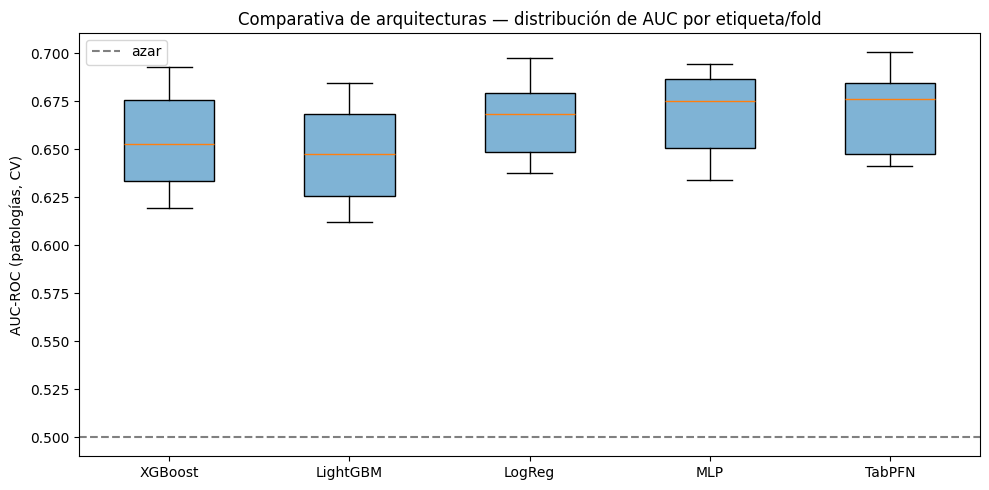

Diagrama de cajas guardado.


In [12]:
# CELDA 11 · TABLA COMPARATIVA + DIAGRAMA DE CAJAS DE AUC
print(f"{'Modelo':10s} {'macroAUC_path':>15} {'macroAUC_core':>15}")
print("-"*42); rank=[]
for n in MODELS:
    om=multilabel_metrics(oof[n],y_train,m_train)
    print(f"{n:10s} {np.mean(fold_macro[n]):.4f} ± {np.std(fold_macro[n]):.4f}      {om['macro_AUC_core']:.4f}")
    rank.append((n,float(np.mean(fold_macro[n]))))
rank.sort(key=lambda x:-x[1]); BEST_MODEL=rank[0][0]
print(f"\n>>> Mejor arquitectura: {BEST_MODEL} (macroAUC_path={rank[0][1]:.4f})")

# Diagrama de cajas: distribución de AUC (todas las etiquetas × folds) por modelo
fig,ax=plt.subplots(figsize=(10,5))
data=[[a for l in PATHOLOGY_LABELS for a in perlabel_auc[n][l] if not np.isnan(a)] for n in MODELS]
bp=ax.boxplot(data,labels=MODELS,patch_artist=True)
for patch in bp["boxes"]: patch.set_facecolor("#7fb3d5")
ax.axhline(0.5,color="gray",ls="--",label="azar"); ax.set_ylabel("AUC-ROC (patologías, CV)")
ax.set_title("Comparativa de arquitecturas — distribución de AUC por etiqueta/fold"); ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR/"boxplot_auc_modelos.png",dpi=150,bbox_inches="tight"); plt.show()
print("Diagrama de cajas guardado.")


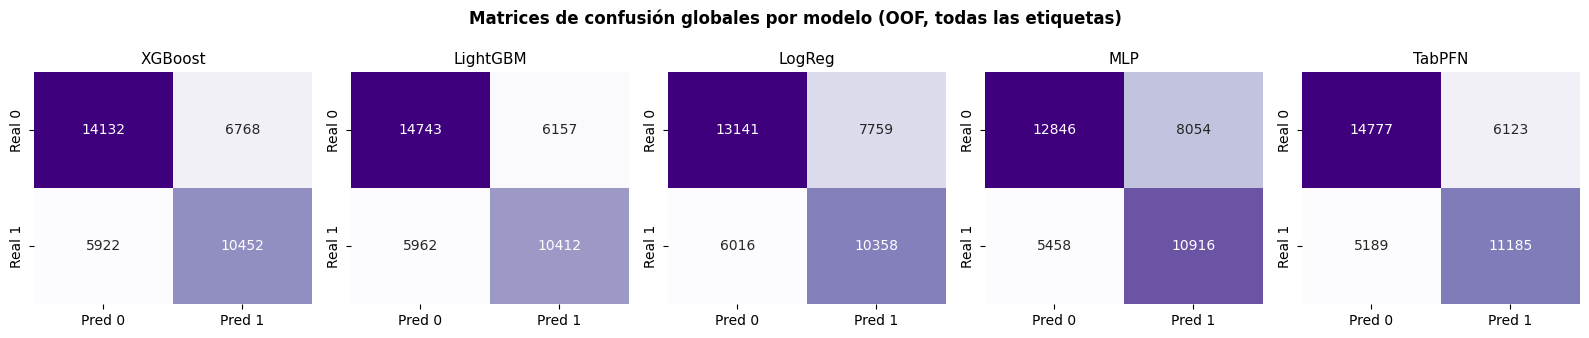

Matrices de confusión por modelo guardadas.


In [13]:
# CELDA 12 · MATRICES DE CONFUSIÓN POR MODELO (global, sobre OOF, umbral 0.5)
fig,axes=plt.subplots(1,len(MODELS),figsize=(3.2*len(MODELS),3.4))
if len(MODELS)==1: axes=[axes]
for ax,n in zip(axes,MODELS):
    yt_all=[]; yp_all=[]
    for j in range(N_LABELS):
        s=m_train[:,j]==1; yt_all.append(y_train[s,j]); yp_all.append((oof[n][s,j]>=0.5).astype(int))
    yt_all=np.concatenate(yt_all); yp_all=np.concatenate(yp_all)
    cm=confusion_matrix(yt_all,yp_all,labels=[0,1])
    sns.heatmap(cm,annot=True,fmt="d",cmap="Purples",cbar=False,ax=ax,
                xticklabels=["Pred 0","Pred 1"],yticklabels=["Real 0","Real 1"])
    ax.set_title(n,fontsize=11)
fig.suptitle("Matrices de confusión globales por modelo (OOF, todas las etiquetas)",fontweight="bold")
plt.tight_layout(); plt.savefig(FIG_DIR/"confusion_por_modelo.png",dpi=150,bbox_inches="tight"); plt.show()
print("Matrices de confusión por modelo guardadas.")


In [14]:
# CELDA 13 · MEJOR MODELO: TUNING (Optuna) + ENTRENAMIENTO FINAL SERIO
# Si el mejor es un GBM, se afina con Optuna; si no, se reentrena con buena config.
def cv_macro_gbm(make, cfg):
    kf=KFold(3,shuffle=True,random_state=SEED); sc=[]
    for tr,va in kf.split(np.arange(len(df_train))):
        pv=ovr_fit_predict(lambda spw: make(spw,cfg), X_tree_tr[tr], y_train[tr], m_train[tr], X_tree_tr[va])
        sc.append(multilabel_metrics(pv,y_train[va],m_train[va])["macro_AUC_path"])
    return float(np.nanmean(sc))

BEST_CFG={}
if BEST_MODEL in ("XGBoost","LightGBM"):
    make = make_xgb if BEST_MODEL=="XGBoost" else make_lgb
    def obj(trial):
        if BEST_MODEL=="XGBoost":
            cfg=dict(n_estimators=trial.suggest_int("n_estimators",300,900,step=100),
                     max_depth=trial.suggest_int("max_depth",3,7),
                     learning_rate=trial.suggest_float("learning_rate",0.01,0.1,log=True),
                     subsample=trial.suggest_float("subsample",0.6,1.0),
                     colsample_bytree=trial.suggest_float("colsample_bytree",0.6,1.0),
                     reg_lambda=trial.suggest_float("reg_lambda",0.1,5.0,log=True))
        else:
            cfg=dict(n_estimators=trial.suggest_int("n_estimators",300,900,step=100),
                     num_leaves=trial.suggest_int("num_leaves",15,127),
                     learning_rate=trial.suggest_float("learning_rate",0.01,0.1,log=True),
                     subsample=trial.suggest_float("subsample",0.6,1.0),
                     colsample_bytree=trial.suggest_float("colsample_bytree",0.6,1.0),
                     reg_lambda=trial.suggest_float("reg_lambda",0.1,5.0,log=True))
        return cv_macro_gbm(make,cfg)
    study=optuna.create_study(direction="maximize",sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(obj,n_trials=OPTUNA_TRIALS_BEST,show_progress_bar=True); BEST_CFG=study.best_params
    print(f"Mejor config {BEST_MODEL}: {BEST_CFG}  (CV macroAUC_path={study.best_value:.4f})")
else:
    print(f"{BEST_MODEL} no usa Optuna aquí; se reentrena con su configuración estándar.")


TabPFN no usa Optuna aquí; se reentrena con su configuración estándar.


In [15]:
# CELDA 14 · ENTRENAR EL MEJOR MODELO EN TODO EL TRAIN Y EVALUAR EN TEST
def fit_predict_final(name, cfg):
    if name=="XGBoost":
        return ovr_fit_predict(lambda spw: make_xgb(spw,cfg), X_tree_tr, y_train, m_train, X_tree_te), \
               ovr_fit_predict(lambda spw: make_xgb(spw,cfg), X_tree_tr, y_train, m_train, X_tree_vl)
    if name=="LightGBM":
        return ovr_fit_predict(lambda spw: make_lgb(spw,cfg), X_tree_tr, y_train, m_train, X_tree_te), \
               ovr_fit_predict(lambda spw: make_lgb(spw,cfg), X_tree_tr, y_train, m_train, X_tree_vl)
    if name=="LogReg":
        return ovr_fit_predict(make_logreg, X_dense_tr, y_train, m_train, X_dense_te, use_spw=False), \
               ovr_fit_predict(make_logreg, X_dense_tr, y_train, m_train, X_dense_vl, use_spw=False)
    if name=="MLP":
        mdl,pt=train_mlp(X_dense_tr,y_train,m_train,X_dense_vl,y_val,m_val,{"lr":1e-3,"dropout":0.3})
        with torch.no_grad():
            mdl.eval(); ptst=torch.sigmoid(mdl(torch.tensor(X_dense_te).to(DEVICE))).cpu().numpy()
        return ptst, pt
    if name=="TabPFN":
        sub=np.arange(len(df_train)) if len(df_train)<=TABPFN_MAX else np.random.RandomState(SEED).choice(len(df_train),TABPFN_MAX,replace=False)
        return ovr_fit_predict(make_tabpfn, X_dense_tr[sub], y_train[sub], m_train[sub], X_dense_te, use_spw=False), \
               ovr_fit_predict(make_tabpfn, X_dense_tr[sub], y_train[sub], m_train[sub], X_dense_vl, use_spw=False)
    raise ValueError(name)

test_pred, val_pred = fit_predict_final(BEST_MODEL, BEST_CFG)
thr_val = best_thresholds_by_f1(val_pred, y_val, m_val)
M = multilabel_metrics(test_pred, y_test, m_test, thresholds=thr_val)
print(f"MEJOR MODELO = {BEST_MODEL}  (entrenado en todo el train)")
print(f"{'Etiqueta':18s} {'AUC':>7} {'AP':>7} {'F1':>7} {'Sens':>6} {'Spec':>6} {'N+':>5} {'N-':>5}")
print("-"*74); rows=[]
for l in LABELS:
    m=M[l]; auc=f"{m['AUC']:.4f}" if not np.isnan(m['AUC']) else "  N/A"
    print(f"{l:18s} {auc:>7} {m['AP']:7.4f} {m['F1']:7.4f} {m['sens']:6.3f} {m['spec']:6.3f} {m['n_pos']:5d} {m['n_neg']:5d}")
    rows.append({"label":l,**{k:m[k] for k in ["AUC","AP","F1","sens","spec","n_pos","n_neg"]}})
print("-"*74); print(f"{'MACRO core':18s} {M['macro_AUC_core']:.4f}  ·  MACRO patol. {M['macro_AUC_path']:.4f}")
pd.DataFrame(rows).to_csv(OUTPUT_DIR/"metrics_best_model.csv",index=False)
json.dump({"best_model":BEST_MODEL,"best_config":BEST_CFG,"test_macro_core":M["macro_AUC_core"],
           "test_macro_path":M["macro_AUC_path"],"per_label":{l:M[l] for l in LABELS}},
          open(OUTPUT_DIR/"summary_labs_v1.json","w",encoding="utf-8"),indent=2,default=str,ensure_ascii=False)
print("Guardados metrics_best_model.csv y summary_labs_v1.json")


00:03 Fitting... Done!
00:05 Predicting... Done!
00:02 Fitting... Done!
00:05 Predicting... Done!
00:02 Fitting... Done!
00:04 Predicting... Done!
00:05 Fitting... Done!
00:03 Predicting... Done!
00:06 Fitting... Done!
00:06 Predicting... Done!
00:04 Fitting... Done!
00:04 Predicting... Done!
00:00 Fitting... -

The provided train set hashes match previously uploaded train sets.


00:00 Fitting... Done!
00:03 Predicting... Done!
00:00 Fitting... -

The provided train set hashes match previously uploaded train sets.


00:00 Fitting... Done!
00:04 Predicting... Done!
00:00 Fitting... \

...

00:00 Fitting... Done!
00:03 Predicting... Done!
00:00 Fitting... -

The provided train set hashes match previously uploaded train sets.


00:00 Fitting... Done!
00:04 Predicting... Done!
00:00 Fitting... -

The provided train set hashes match previously uploaded train sets.


00:00 Fitting... Done!
00:06 Predicting... Done!
MEJOR MODELO = TabPFN  (entrenado en todo el train)
Etiqueta               AUC      AP      F1   Sens   Spec    N+    N-
--------------------------------------------------------------------------
Atelectasis         0.6677  0.7161  0.7562  0.979  0.095   141    95
Cardiomegaly        0.6352  0.6378  0.7003  0.917  0.229   144   131
Edema               0.7269  0.4916  0.5423  0.939  0.313    82   182
Lung Opacity        0.6798  0.7274  0.7432  0.939  0.163   131    92
No Finding          0.6992  0.3381  0.3608  0.507  0.742    69   349
Pleural Effusion    0.6887  0.6996  0.7031  0.892  0.340   166   162
--------------------------------------------------------------------------
MACRO core         0.6836  ·  MACRO patol. 0.6797
Guardados metrics_best_model.csv y summary_labs_v1.json


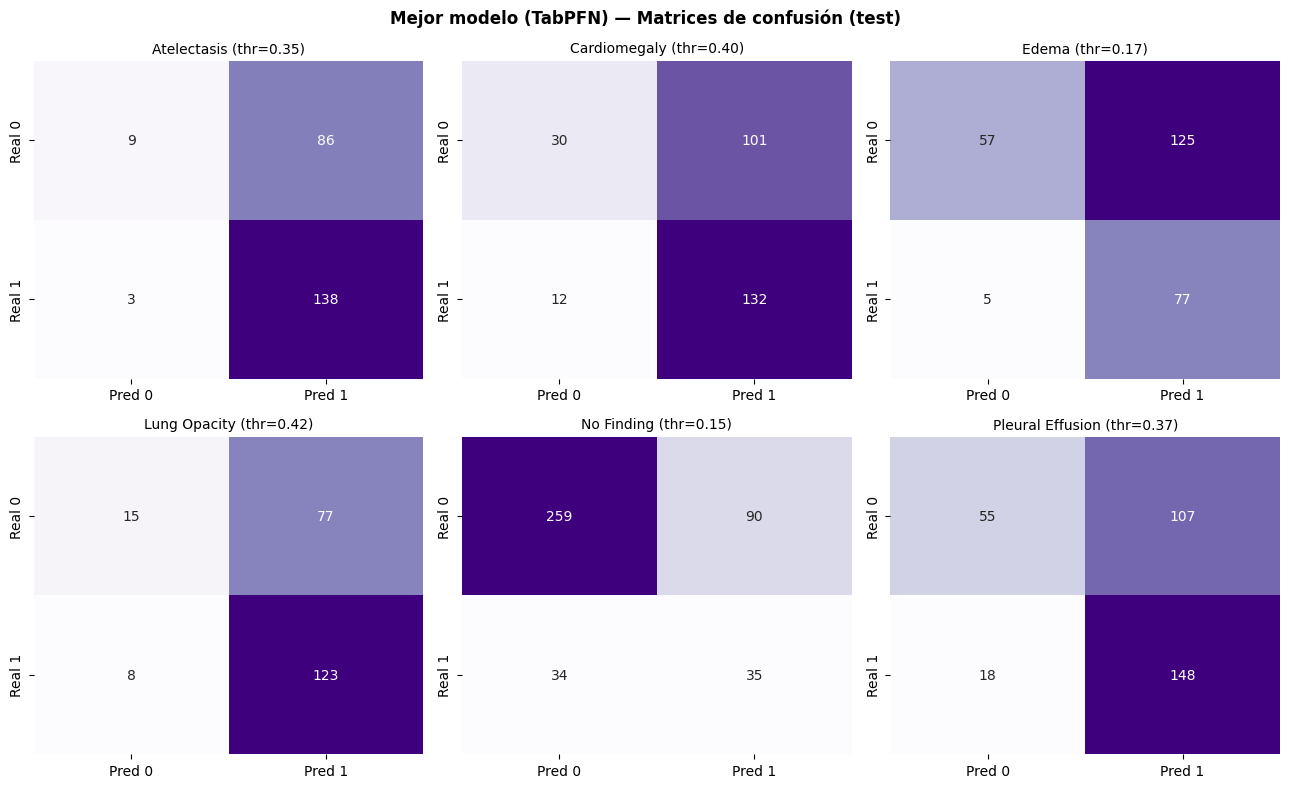

Matrices de confusión del mejor modelo guardadas.


In [16]:
# CELDA 15 · MATRICES DE CONFUSIÓN DEL MEJOR MODELO (test, por etiqueta)
fig,axes=plt.subplots(2,3,figsize=(13,8)); fig.suptitle(f"Mejor modelo ({BEST_MODEL}) — Matrices de confusión (test)",fontweight="bold")
for j,l in enumerate(LABELS):
    ax=axes[j//3,j%3]; s=m_test[:,j]==1; yt=y_test[s,j]; yp=(test_pred[s,j]>=thr_val.get(l,0.5)).astype(int)
    if len(yt)==0: ax.axis("off"); continue
    cm=confusion_matrix(yt,yp,labels=[0,1])
    sns.heatmap(cm,annot=True,fmt="d",cmap="Purples",cbar=False,ax=ax,
                xticklabels=["Pred 0","Pred 1"],yticklabels=["Real 0","Real 1"])
    ax.set_title(f"{l} (thr={thr_val.get(l,0.5):.2f})",fontsize=10)
plt.tight_layout(); plt.savefig(FIG_DIR/"confusion_mejor_modelo.png",dpi=150,bbox_inches="tight"); plt.show()
print("Matrices de confusión del mejor modelo guardadas.")


In [17]:
# CELDA 16 · IMPORTANCIA DE VARIABLES (si el mejor es de árboles) con nombres legibles
if BEST_MODEL in ("XGBoost","LightGBM"):
    make = make_xgb if BEST_MODEL=="XGBoost" else make_lgb
    imp=np.zeros(X_tree_tr.shape[1])
    for j in range(N_LABELS):
        sel=m_train[:,j]==1; yj=y_train[sel,j]
        if len(np.unique(yj))<2: continue
        spw=(yj==0).sum()/max((yj==1).sum(),1); clf=make(spw,BEST_CFG); clf.fit(X_tree_tr[sel],yj)
        fi=clf.feature_importances_; imp+=fi/ (fi.sum()+1e-9)
    imp/=N_LABELS
    order=np.argsort(imp)[::-1][:20]
    fig,ax=plt.subplots(figsize=(9,7))
    ax.barh([TREE_NAMES[i] for i in order][::-1],[imp[i] for i in order][::-1],color="#5b8db8")
    ax.set_title(f"Importancia media de variables — {BEST_MODEL} (top 20)"); ax.set_xlabel("importancia (norm.)")
    plt.tight_layout(); plt.savefig(FIG_DIR/"importancia_variables.png",dpi=150,bbox_inches="tight"); plt.show()
    print("Top-10 variables:")
    for i in order[:10]: print(f"   {TREE_NAMES[i]:45s} {imp[i]:.4f}")
else:
    print(f"El mejor modelo ({BEST_MODEL}) no es de árboles; importancia por permutación quedaría como mejora futura.")


El mejor modelo (TabPFN) no es de árboles; importancia por permutación quedaría como mejora futura.


In [18]:
# CELDA 17 · EQUIDAD POR SUBGRUPO (mejor modelo, test)
dft=df_test.reset_index(drop=True)
for col,lab in [("gender","GÉNERO"),("race","RAZA"),("admission_type","INGRESO")]:
    if col not in dft.columns: continue
    print(f"\n-- AUC macro (patologías) por {lab} --")
    for v in sorted(dft[col].dropna().unique(),key=str):
        idx=dft.index[dft[col]==v].to_numpy()
        if len(idx)<15: print(f"   {str(v):22s} n={len(idx):4d} (insuficiente)"); continue
        mm=multilabel_metrics(test_pred[idx],y_test[idx],m_test[idx])
        print(f"   {str(v):22s} n={len(idx):4d}  macroAUC_path={mm['macro_AUC_path']:.4f}")
print("\nEquidad completada.")



-- AUC macro (patologías) por GÉNERO --
   0                      n= 184  macroAUC_path=0.6421
   1                      n= 280  macroAUC_path=0.7016

-- AUC macro (patologías) por RAZA --
   ASIAN                  n=  15  macroAUC_path=0.7737
   BLACK                  n=  58  macroAUC_path=0.5124
   HISPANIC_LATINO        n=  21  macroAUC_path=0.5271
   OTHER_KNOWN            n=   3 (insuficiente)
   UNKNOWN                n=  52  macroAUC_path=0.6356
   WHITE                  n= 315  macroAUC_path=0.7236

-- AUC macro (patologías) por INGRESO --
   EMERGENCY              n= 322  macroAUC_path=0.6345
   OBSERVATION            n=  66  macroAUC_path=0.7667
   SCHEDULED              n=  34  macroAUC_path=0.6200
   URGENT                 n=  42  macroAUC_path=0.7247

Equidad completada.


---
## ✅ Conclusión — Módulo tabular (laboratorio)

**Qué hace:** predice las 6 etiquetas solo con analíticas de sangre + contexto clínico, comparando 5 arquitecturas
y entrenando en serio la mejor.

**Decisiones tomadas:** raw para árboles / percentil imputado para densos · flags de missingness (señal MNAR) ·
41 analíticas + contexto · enmascarado + negativos derivados de *No Finding* · corrección de desequilibrio por etiqueta
(`scale_pos_weight`, `class_weight`, `pos_weight`/focal) · **AUC-ROC macro** como métrica principal.

**Qué esperar (cualitativo, según EDA):** la señal tabular es **limitada pero real**, sobre todo en **Cardiomegaly,
Edema y Pleural Effusion** (perfil cardio-renal); en **Atelectasis y Lung Opacity** las analíticas apenas discriminan
(esas se aprenden desde la imagen). Por eso este módulo es **complementario**.

**Salidas:** `boxplot_auc_modelos.png`, `confusion_por_modelo.png`, `confusion_mejor_modelo.png`,
`importancia_variables.png`, `metrics_best_model.csv`, `summary_labs_v1.json`.

**Independiente:** no exporta predicciones por muestra ni depende de ninguna fusión.
